# DMEPOS Amount Stats Exploratory Data Analysis (EDA)

In this notebook we perform univariate and bivariate statistical analysis of the `full_dmepos_amount_stats_labeled.csv` dataset then remove features before outputting `dmepos_amount_stats_labeled.csv`.

## WARNING! The following notebook must be run before this one.
* SpIn_2_Artifacts/full_dmepos_amount_stats_labeled_silver.ipynb

## Import the data

In [1]:
import pandas as pd

df = pd.read_csv('/dsa/groups/casestudycf25/team02/silver/dmepos_amount_stats_labeled.csv')
df.head()

,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,...,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre,og_specialty_name
0,1003000597,OK,2022,0,6.155416,2.196826,1.692306,1.702371,10077.68000,0.166923,...,-1.0,0.687500,0.812500,-1.0,0.0,0.0,-1.000000,0.0,1.822832,urology
1,1003000597,OK,2023,0,12.431501,6.574868,4.766645,5.263697,12026.49000,-0.030055,...,-1.0,0.714286,0.857143,-1.0,0.0,0.0,-1.000000,-1.0,1.717712,urology
2,1003000902,KY,2021,0,97.751851,26.709274,19.463974,18.978969,815.74625,-0.297531,...,-1.0,0.870968,0.967742,-1.0,-1.0,0.0,0.516129,-1.0,1.839028,family_practice
3,1003000902,KY,2022,0,80.839496,18.260912,13.472218,12.561403,264.37400,-0.438026,...,-1.0,0.782609,0.913043,-1.0,-1.0,0.0,0.521739,-1.0,1.358490,family_practice
4,1003000902,KY,2023,0,39.630693,14.071564,10.200556,10.291238,217.24000,-0.366585,...,-1.0,0.833333,0.875000,-1.0,0.0,-1.0,-1.000000,-1.0,1.498885,family_practice


In [2]:
df.shape

(140827, 116)

## Univariate analysis

In [3]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [4]:
# first split the data into three datasets and keep only the feature (everything after the 4th column, target)
# don't include one-hot encodings
# i.e. get avg_suplr_sbmt_chrg_mean thru bene_avg_risk_scre

X_tot = df.loc[:,'avg_suplr_sbmtd_chrg_mean':'bene_avg_risk_scre'] # all
X_non = df[df.target==0].loc[:,'avg_suplr_sbmtd_chrg_mean':'bene_avg_risk_scre'] # non-fraud
X_frd = df[df.target==1].loc[:,'avg_suplr_sbmtd_chrg_mean':'bene_avg_risk_scre'] # fraud

In [5]:
X_tot.describe().T

,count,mean,std,min,25%,50%,75%,max
avg_suplr_sbmtd_chrg_mean,140827.0,264.241714,624.218019,0.011182,73.546203,143.710069,252.779678,2.100000e+04
avg_suplr_mdcr_alowd_amt_mean,140827.0,108.998601,383.054231,0.010558,26.480000,53.632984,86.926203,1.528944e+04
avg_suplr_mdcr_pymt_amt_mean,140827.0,83.715960,301.735346,0.000000,19.434901,40.037500,65.636188,1.198692e+04
avg_suplr_mdcr_stdzd_amt_mean,140827.0,83.490240,299.543128,0.000000,20.017008,40.588116,62.959259,1.198692e+04
avg_suplr_sbmtd_chrg_sum,140827.0,1180.083037,2005.306888,0.011182,155.353663,534.127665,1403.243425,1.784867e+05
avg_suplr_mdcr_alowd_amt_sum,140827.0,443.819095,947.938998,0.010558,67.442458,184.386154,483.422637,1.216627e+05
avg_suplr_mdcr_pymt_amt_sum,140827.0,338.383343,737.240101,0.000000,50.080000,137.543136,363.802523,9.473796e+04
avg_suplr_mdcr_stdzd_amt_sum,140827.0,334.447650,724.854847,0.000000,51.180672,131.510909,359.286854,9.397049e+04
avg_suplr_sbmtd_chrg_median,140827.0,203.656041,611.633103,0.011182,50.730000,80.901786,170.628688,2.100000e+04
avg_suplr_mdcr_alowd_amt_median,140827.0,86.362379,377.920001,0.010558,11.645000,30.115000,63.270000,1.528944e+04


In [6]:
X_non.describe().T

,count,mean,std,min,25%,50%,75%,max
avg_suplr_sbmtd_chrg_mean,140771.0,264.232839,624.273468,0.011182,73.533309,143.706718,252.775808,2.100000e+04
avg_suplr_mdcr_alowd_amt_mean,140771.0,108.995254,383.115512,0.010558,26.478231,53.631400,86.903841,1.528944e+04
avg_suplr_mdcr_pymt_amt_mean,140771.0,83.713315,301.783680,0.000000,19.433699,40.035049,65.625256,1.198692e+04
avg_suplr_mdcr_stdzd_amt_mean,140771.0,83.487929,299.591073,0.000000,20.015518,40.587727,62.949389,1.198692e+04
avg_suplr_sbmtd_chrg_sum,140771.0,1179.822188,2005.185939,0.011182,155.310606,534.039748,1402.671097,1.784867e+05
avg_suplr_mdcr_alowd_amt_sum,140771.0,443.686743,947.912547,0.010558,67.380123,184.339189,483.299334,1.216627e+05
avg_suplr_mdcr_pymt_amt_sum,140771.0,338.280733,737.218895,0.000000,50.080000,137.516795,363.728468,9.473796e+04
avg_suplr_mdcr_stdzd_amt_sum,140771.0,334.350558,724.837468,0.000000,51.123223,131.502333,359.169710,9.397049e+04
avg_suplr_sbmtd_chrg_median,140771.0,203.662547,611.688515,0.011182,50.730000,80.902917,170.632483,2.100000e+04
avg_suplr_mdcr_alowd_amt_median,140771.0,86.370928,377.984066,0.010558,11.645000,30.117273,63.270000,1.528944e+04


In [7]:
X_frd.describe().T

,count,mean,std,min,25%,50%,75%,max
avg_suplr_sbmtd_chrg_mean,56.0,286.550922,468.018353,13.530000,107.554450,158.990864,266.275996,3317.739231
avg_suplr_mdcr_alowd_amt_mean,56.0,117.411805,170.749751,4.883333,31.942083,64.052771,102.175532,1060.380000
avg_suplr_mdcr_pymt_amt_mean,56.0,90.363227,134.142783,3.257361,23.813045,46.096059,80.531542,831.330000
avg_suplr_mdcr_stdzd_amt_mean,56.0,89.299852,133.419473,3.218194,24.052460,48.024755,89.721406,831.330000
avg_suplr_sbmtd_chrg_sum,56.0,1835.796815,2213.126125,34.333176,369.952469,825.019130,2486.964481,10468.515336
avg_suplr_mdcr_alowd_amt_sum,56.0,776.520328,964.638649,7.952500,138.554878,261.987656,1139.413111,3777.576540
avg_suplr_mdcr_pymt_amt_sum,56.0,596.321469,752.107767,5.632500,97.087637,190.150716,867.146509,2895.601504
avg_suplr_mdcr_stdzd_amt_sum,56.0,578.514955,734.013436,5.465000,103.290895,203.244517,849.571636,2900.289949
avg_suplr_sbmtd_chrg_median,56.0,187.300796,455.111004,7.557688,53.948054,73.897089,145.077500,3317.739231
avg_suplr_mdcr_alowd_amt_median,56.0,64.871119,144.924740,4.883333,16.456480,27.121250,58.883397,1060.380000


Since the variables lie on radically different scales, we cannot directly compare measures of variability. However, we can derive comparable metrics based on ratios. Here we take variability measures, standard deviation and interquartile range, and scale them by the inverse range for each feature.

In [8]:
# calculate ratio of std to range and iqr to range for total data
X_tot_var = X_tot.describe().T.drop(columns=['count','mean','50%'])
X_tot_var['iqr'] = X_tot_var['75%'] - X_tot_var['25%']
X_tot_var['range'] = X_tot_var['max'] - X_tot_var['min']
X_tot_var['std_range_rat'] = X_tot_var['std']/X_tot_var['range']
X_tot_var['iqr_range_rat'] = X_tot_var['iqr']/X_tot_var['range']
X_tot_var = X_tot_var.drop(columns=['min','25%','75%','max'])

# calculate ratio of std to range and iqr to range for non-fraud data
X_non_var = X_non.describe().T.drop(columns=['count','mean','50%'])
X_non_var['iqr'] = X_non_var['75%'] - X_non_var['25%']
X_non_var['range'] = X_non_var['max'] - X_non_var['min']
X_non_var['std_range_rat'] = X_non_var['std']/X_non_var['range']
X_non_var['iqr_range_rat'] = X_non_var['iqr']/X_non_var['range']
X_non_var = X_non_var.drop(columns=['min','25%','75%','max'])

# calculate ratio of std to range and iqr to range for fraud data
X_frd_var = X_frd.describe().T.drop(columns=['count','mean','50%'])
X_frd_var['iqr'] = X_frd_var['75%'] - X_frd_var['25%']
X_frd_var['range'] = X_frd_var['max'] - X_frd_var['min']
X_frd_var['std_range_rat'] = X_frd_var['std']/X_frd_var['range']
X_frd_var['iqr_range_rat'] = X_frd_var['iqr']/X_frd_var['range']
X_frd_var = X_frd_var.drop(columns=['min','25%','75%','max'])


### Total Dataset

In [9]:
X_tot_var_std_sorted = X_tot_var.sort_values(by='std_range_rat', ascending=False)
X_tot_var_std_fts = X_tot_var_std_sorted.index

In [10]:
X_tot_var_iqr_sorted = X_tot_var.sort_values(by='iqr_range_rat', ascending=False)
X_tot_var_iqr_fts = X_tot_var_iqr_sorted.index

### Non-fraudulent providers

In [11]:
X_non_var_std_sorted = X_non_var.sort_values(by='std_range_rat', ascending=False)
X_non_var_std_fts = X_non_var_std_sorted.index

In [12]:
X_non_var_iqr_sorted = X_non_var.sort_values(by='iqr_range_rat', ascending=False)
X_non_var_iqr_fts = X_non_var_iqr_sorted.index

### Fraudulent providers

In [13]:
X_frd_var_std_sorted = X_frd_var.sort_values(by='std_range_rat', ascending=False)
X_frd_var_std_fts = X_frd_var_std_sorted.index

In [14]:
X_frd_var_iqr_sorted = X_non_var.sort_values(by='iqr_range_rat', ascending=False)
X_frd_var_iqr_fts = X_frd_var_iqr_sorted.index

### Total compared to non-fraudulent

In [15]:
X_tot_var_std_fts[X_tot_var_std_fts != X_non_var_std_fts]

Index([], dtype='object')

In [16]:
X_tot_var_iqr_fts[X_tot_var_iqr_fts != X_non_var_iqr_fts]

Index([], dtype='object')

Since the order of features based on the ratios calculated is the same regardless of whether we are analyzing the total dataset or just non-fraudulent providers, it suffices to merely compare the fraudulent and non-fraudulent providers.

### Non-fraudulent compared to fraudulent

In [17]:
X_non_var_std_fts[X_non_var_std_fts != X_frd_var_std_fts] # non-fraudulent features ordered differently by std/range

Index(['bene_cc_ph_hypertension_v2_pct', 'bene_cc_ph_hyperlipidemia_v2_pct',
       'hi_risk_hcpcs', 'bene_cc_ph_diabetes_v2_pct',
       'bene_cc_ph_arthritis_v2_pct', 'bene_cc_bh_ptsd_v1_pct',
       'bene_cc_bh_adhd_oth_cd_v1_pct', 'bene_cc_ph_ischemic_heart_v2_pct',
       'bene_cc_ph_copd_v2_pct', 'bene_cc_bh_mood_v2_pct',
       'bene_cc_bh_anxiety_v1_pct', 'bene_cc_bh_depress_v1_pct',
       'bene_cc_ph_hf_non_ihd_v2_pct', 'bene_cc_bh_pd_v1_pct',
       'bene_cc_ph_afib_v2_pct', 'bene_cc_bh_schizo_oth_psy_v1_pct',
       'bene_cc_bh_bipolar_v1_pct', 'bene_cc_ph_parkinson_v2_pct',
       'bene_cc_ph_cancer6_v2_pct', 'bene_cc_bh_tobacco_v1_pct',
       'bene_cc_ph_osteoporosis_v2_pct', 'bene_cc_bh_alz_non_alzdem_v2_pct',
       'bene_cc_bh_alcohol_drug_v1_pct', 'bene_cc_ph_asthma_v2_pct',
       'bene_cc_ph_stroke_tia_v2_pct', 'tot_suplr_nonrntl_hcpcs_cds',
       'tot_suplr_rentl_hcpcs_cds', 'tot_suplrs_min', 'bene_avg_age',
       'tot_suplrs_median', 'tot_suplrs_mean', 'tot_sup

In [18]:
X_frd_var_std_fts[X_non_var_std_fts != X_frd_var_std_fts] # fraudulent features ordered differently by std/range

Index(['bene_cc_bh_adhd_oth_cd_v1_pct', 'bene_cc_bh_ptsd_v1_pct',
       'bene_race_api_cnt', 'bene_race_othr_cnt', 'bene_cc_bh_pd_v1_pct',
       'bene_cc_ph_parkinson_v2_pct', 'bene_cc_ph_hypertension_v2_pct',
       'bene_cc_ph_hyperlipidemia_v2_pct', 'bene_cc_ph_ischemic_heart_v2_pct',
       'bene_cc_ph_diabetes_v2_pct', 'bene_cc_ph_arthritis_v2_pct',
       'bene_cc_ph_hf_non_ihd_v2_pct', 'bene_cc_ph_afib_v2_pct',
       'bene_cc_ph_cancer6_v2_pct', 'bene_cc_bh_mood_v2_pct',
       'bene_cc_ph_copd_v2_pct', 'bene_cc_bh_depress_v1_pct',
       'bene_cc_bh_alz_non_alzdem_v2_pct', 'bene_cc_ph_stroke_tia_v2_pct',
       'bene_cc_bh_anxiety_v1_pct', 'bene_cc_ph_asthma_v2_pct',
       'bene_cc_bh_tobacco_v1_pct', 'bene_cc_bh_schizo_oth_psy_v1_pct',
       'bene_cc_ph_osteoporosis_v2_pct', 'bene_cc_bh_bipolar_v1_pct',
       'tot_suplr_benes_median', 'bene_cc_bh_alcohol_drug_v1_pct',
       'tot_suplrs_sum', 'bene_male_cnt', 'bene_age_65_74_cnt',
       'bene_race_wht_cnt', 'avg_suplr_m

In [19]:
X_non_var_std_fts != X_frd_var_std_fts # where do they differ?

array([ True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False])

In [20]:
X_non_var_iqr_fts[X_non_var_iqr_fts != X_frd_var_iqr_fts] # non-fraudulent features ordered differently by iqr/range

Index([], dtype='object')

In [21]:
X_frd_var_iqr_fts[X_non_var_iqr_fts != X_frd_var_iqr_fts] # fraudulent features ordered differently by iqr/range

Index([], dtype='object')

After sorting the features for each dataset by the ratio of standard deviation to range in descending order, we find the first difference among the orderings for the three data sets occurs at the seventh feature which is `bene_cc_ph_hf_non_ihd_v2_pct` for fraudulent providers but `bene_cc_ph_copd_v2_pct` for non-fraudent provider and the total dataset. The orderings of the features for the fraudulent and non-fraudulent subsets differ for all subsequent features. However, we find all datasets share the same feature ordering based on the ratio of interquartile range to range. As the latter method is not sensitive to outliers, we conclude that the fraudulent and non-fraudulent subsets are best distinguished by extreme values.

In [22]:
X_non_var_std_fts[X_non_var_std_fts == X_frd_var_std_fts] # features with the same std/range ranking btwn frd & non

Index(['bene_cc_ph_ckd_v2_pct', 'tot_suplr_benes_min'], dtype='object')

In [23]:
X_tot_var_std_sorted # inspect the overall std/range dataframe

,std,iqr,range,std_range_rat,iqr_range_rat
bene_cc_ph_hypertension_v2_pct,0.890547,1.904762,2.000000e+00,0.445273,0.952381
bene_cc_ph_hyperlipidemia_v2_pct,0.877355,1.833333,2.000000e+00,0.438677,0.916667
hi_risk_hcpcs,0.410603,0.000000,1.000000e+00,0.410603,0.000000
bene_cc_ph_diabetes_v2_pct,0.815293,1.602564,2.000000e+00,0.407646,0.801282
bene_cc_ph_arthritis_v2_pct,0.786250,1.531250,2.000000e+00,0.393125,0.765625
bene_cc_bh_ptsd_v1_pct,0.493345,1.000000,1.350000e+00,0.365440,0.740741
bene_cc_bh_adhd_oth_cd_v1_pct,0.500028,1.000000,1.458333e+00,0.342876,0.685714
bene_cc_ph_ischemic_heart_v2_pct,0.672499,1.333333,2.000000e+00,0.336249,0.666667
bene_cc_ph_ckd_v2_pct,0.659750,1.275862,2.000000e+00,0.329875,0.637931
bene_cc_ph_copd_v2_pct,0.636793,1.187007,2.000000e+00,0.318396,0.593504


We now create an index object of features ordered (descending) by ratio of standard deviation to range. We adhere to the heuristic that if two features are highly correlated then the feature with greater relative variability should be retained while the other is discarded. 

In [24]:
ordered_fts = X_tot_var_std_sorted.index # features ordered by relative variability

In [25]:
len(ordered_fts)

85

## Univariate visualizations

We determine that univariate visualization will not be informative for features with standard deviations less than five percent of the variable's range. Conceptually, these features are near-constant with a few outliers.

In [26]:
kept_fts = X_tot_var_std_sorted[X_tot_var_std_sorted.std_range_rat > 0.05].index
kept_fts

Index(['bene_cc_ph_hypertension_v2_pct', 'bene_cc_ph_hyperlipidemia_v2_pct',
       'hi_risk_hcpcs', 'bene_cc_ph_diabetes_v2_pct',
       'bene_cc_ph_arthritis_v2_pct', 'bene_cc_bh_ptsd_v1_pct',
       'bene_cc_bh_adhd_oth_cd_v1_pct', 'bene_cc_ph_ischemic_heart_v2_pct',
       'bene_cc_ph_ckd_v2_pct', 'bene_cc_ph_copd_v2_pct',
       'bene_cc_bh_mood_v2_pct', 'bene_cc_bh_anxiety_v1_pct',
       'bene_cc_bh_depress_v1_pct', 'bene_cc_ph_hf_non_ihd_v2_pct',
       'bene_cc_bh_pd_v1_pct', 'bene_cc_ph_afib_v2_pct',
       'bene_cc_bh_schizo_oth_psy_v1_pct', 'bene_cc_bh_bipolar_v1_pct',
       'bene_cc_ph_parkinson_v2_pct', 'bene_cc_ph_cancer6_v2_pct',
       'bene_cc_bh_tobacco_v1_pct', 'bene_cc_ph_osteoporosis_v2_pct',
       'bene_cc_bh_alz_non_alzdem_v2_pct', 'bene_cc_bh_alcohol_drug_v1_pct',
       'bene_cc_ph_asthma_v2_pct', 'bene_cc_ph_stroke_tia_v2_pct',
       'tot_suplr_nonrntl_hcpcs_cds', 'tot_suplr_rentl_hcpcs_cds',
       'tot_suplrs_min', 'bene_avg_age', 'tot_suplrs_median'],
 

We notice that one of the features retained was `hi_risk_hcpcs`. Because this is an indicator variable, it requires different visualization than the continuous-scale variables, so we remove it from the index object `kept_fts`.

In [27]:
kept_fts = kept_fts.delete(2)

In [29]:
len(kept_fts)

30

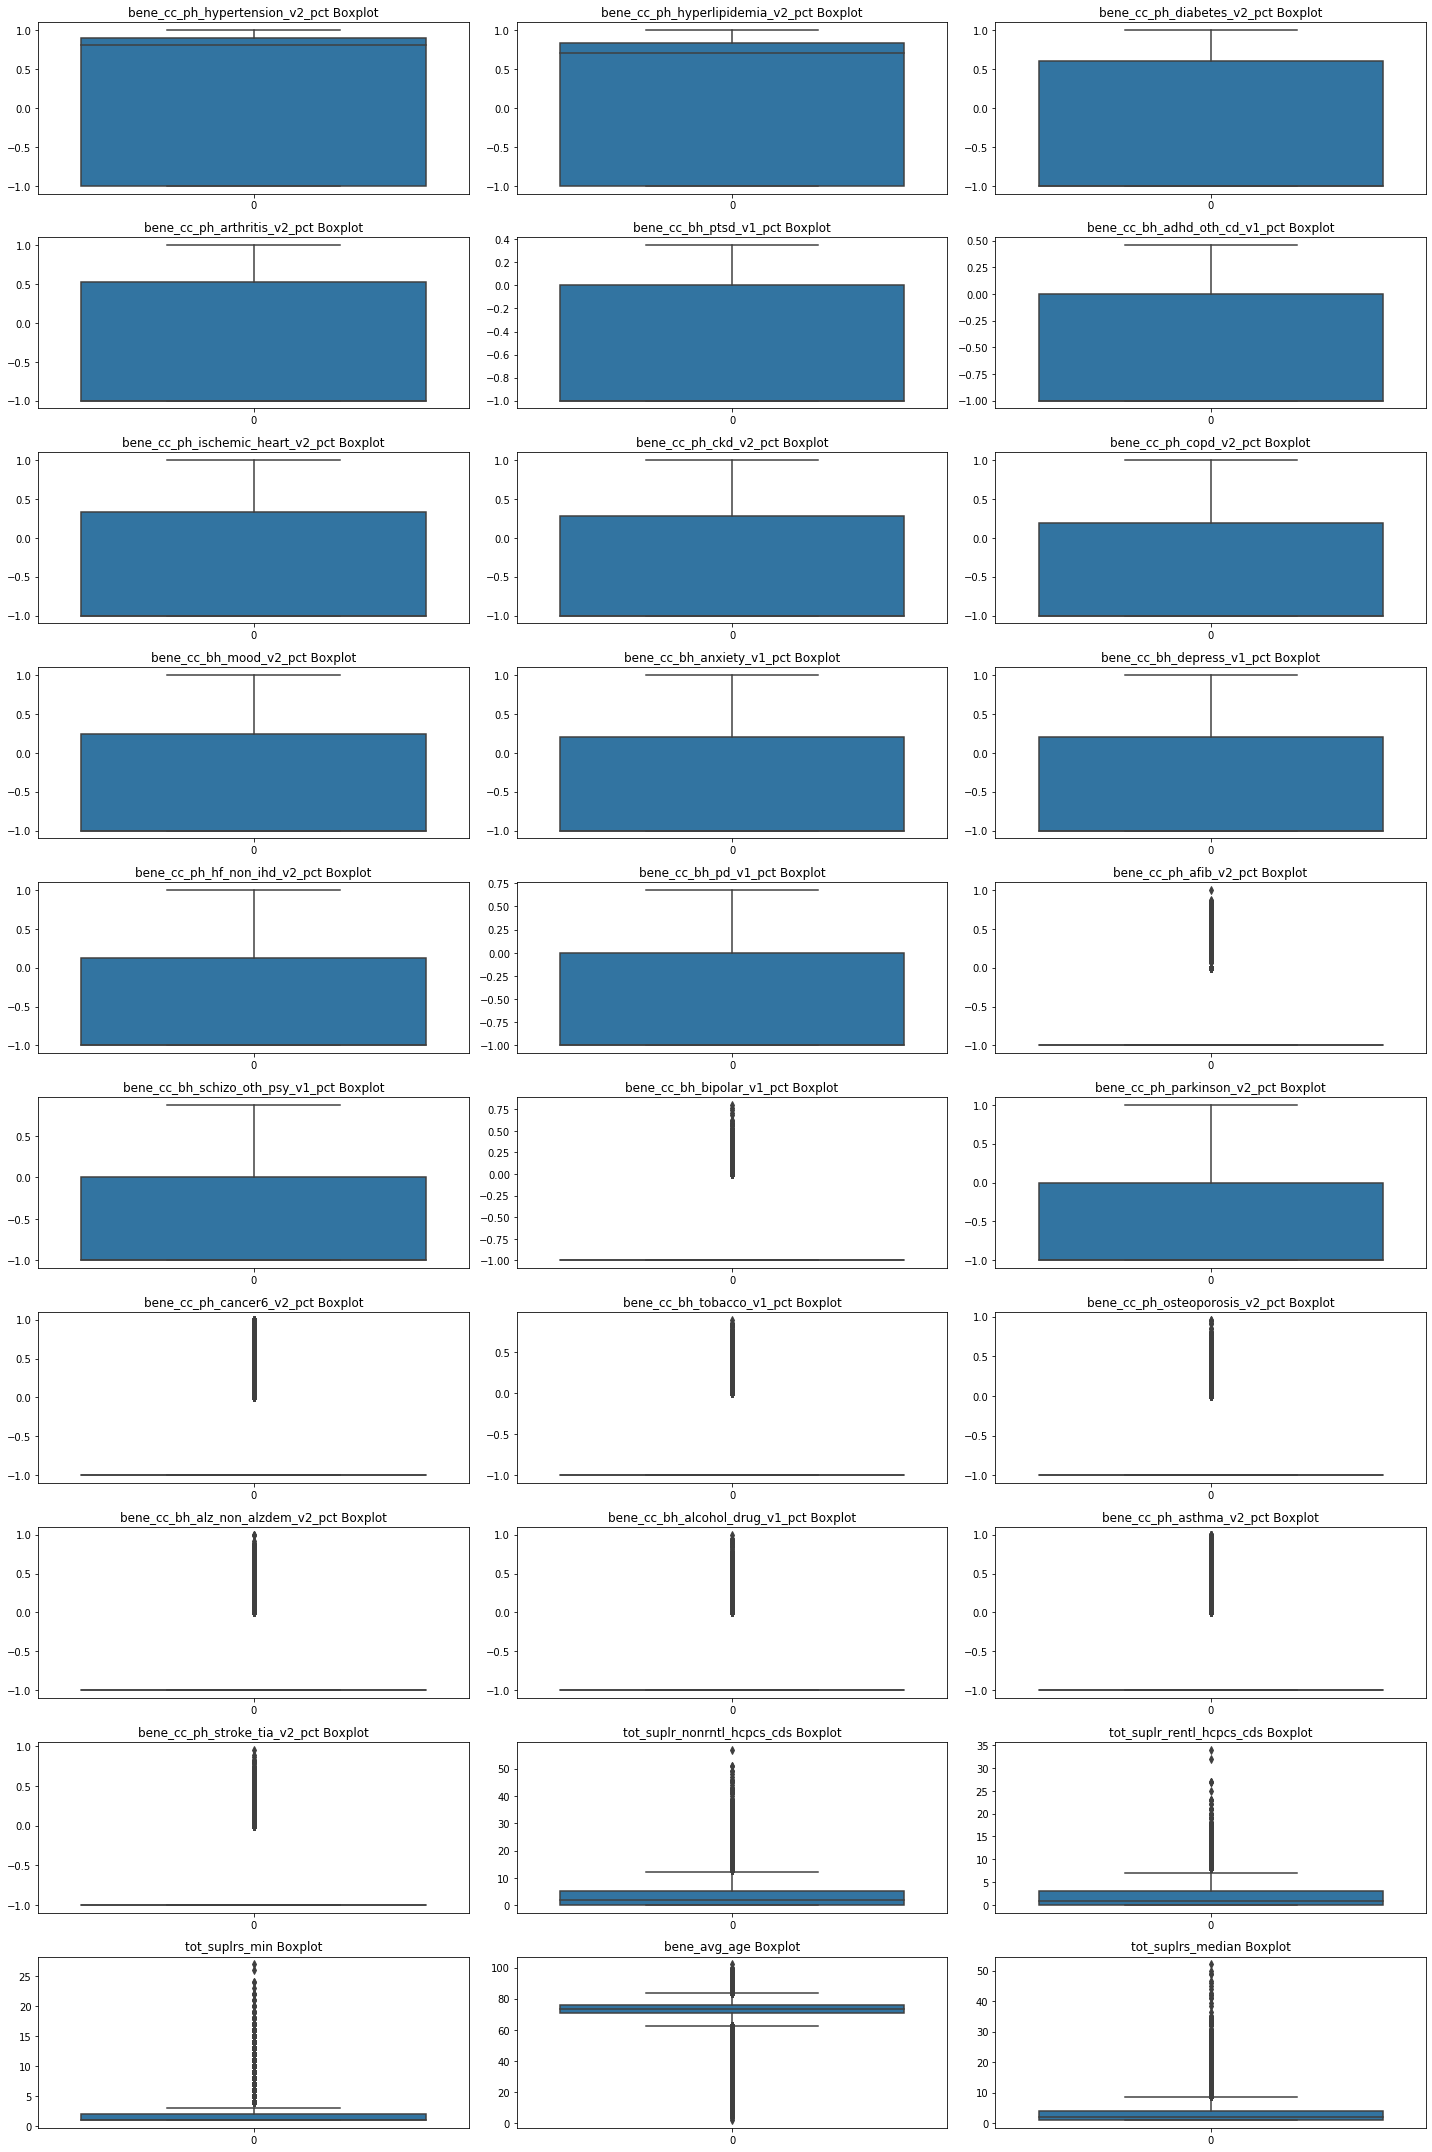

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Which data do I want?
data = X_tot.loc[:,kept_fts]

# Set figure size for high volume
fig, axes = plt.subplots(10, 3, figsize=(20, 30)) # 10 rows, 3 columns
axes = axes.flatten()

# Iterate and plot
for i in range(len(data.columns)):
    sns.boxplot(data=data.iloc[:, i], ax=axes[i])
    axes[i].set_title(f'{data.columns[i]} Boxplot')

plt.tight_layout()
plt.show()


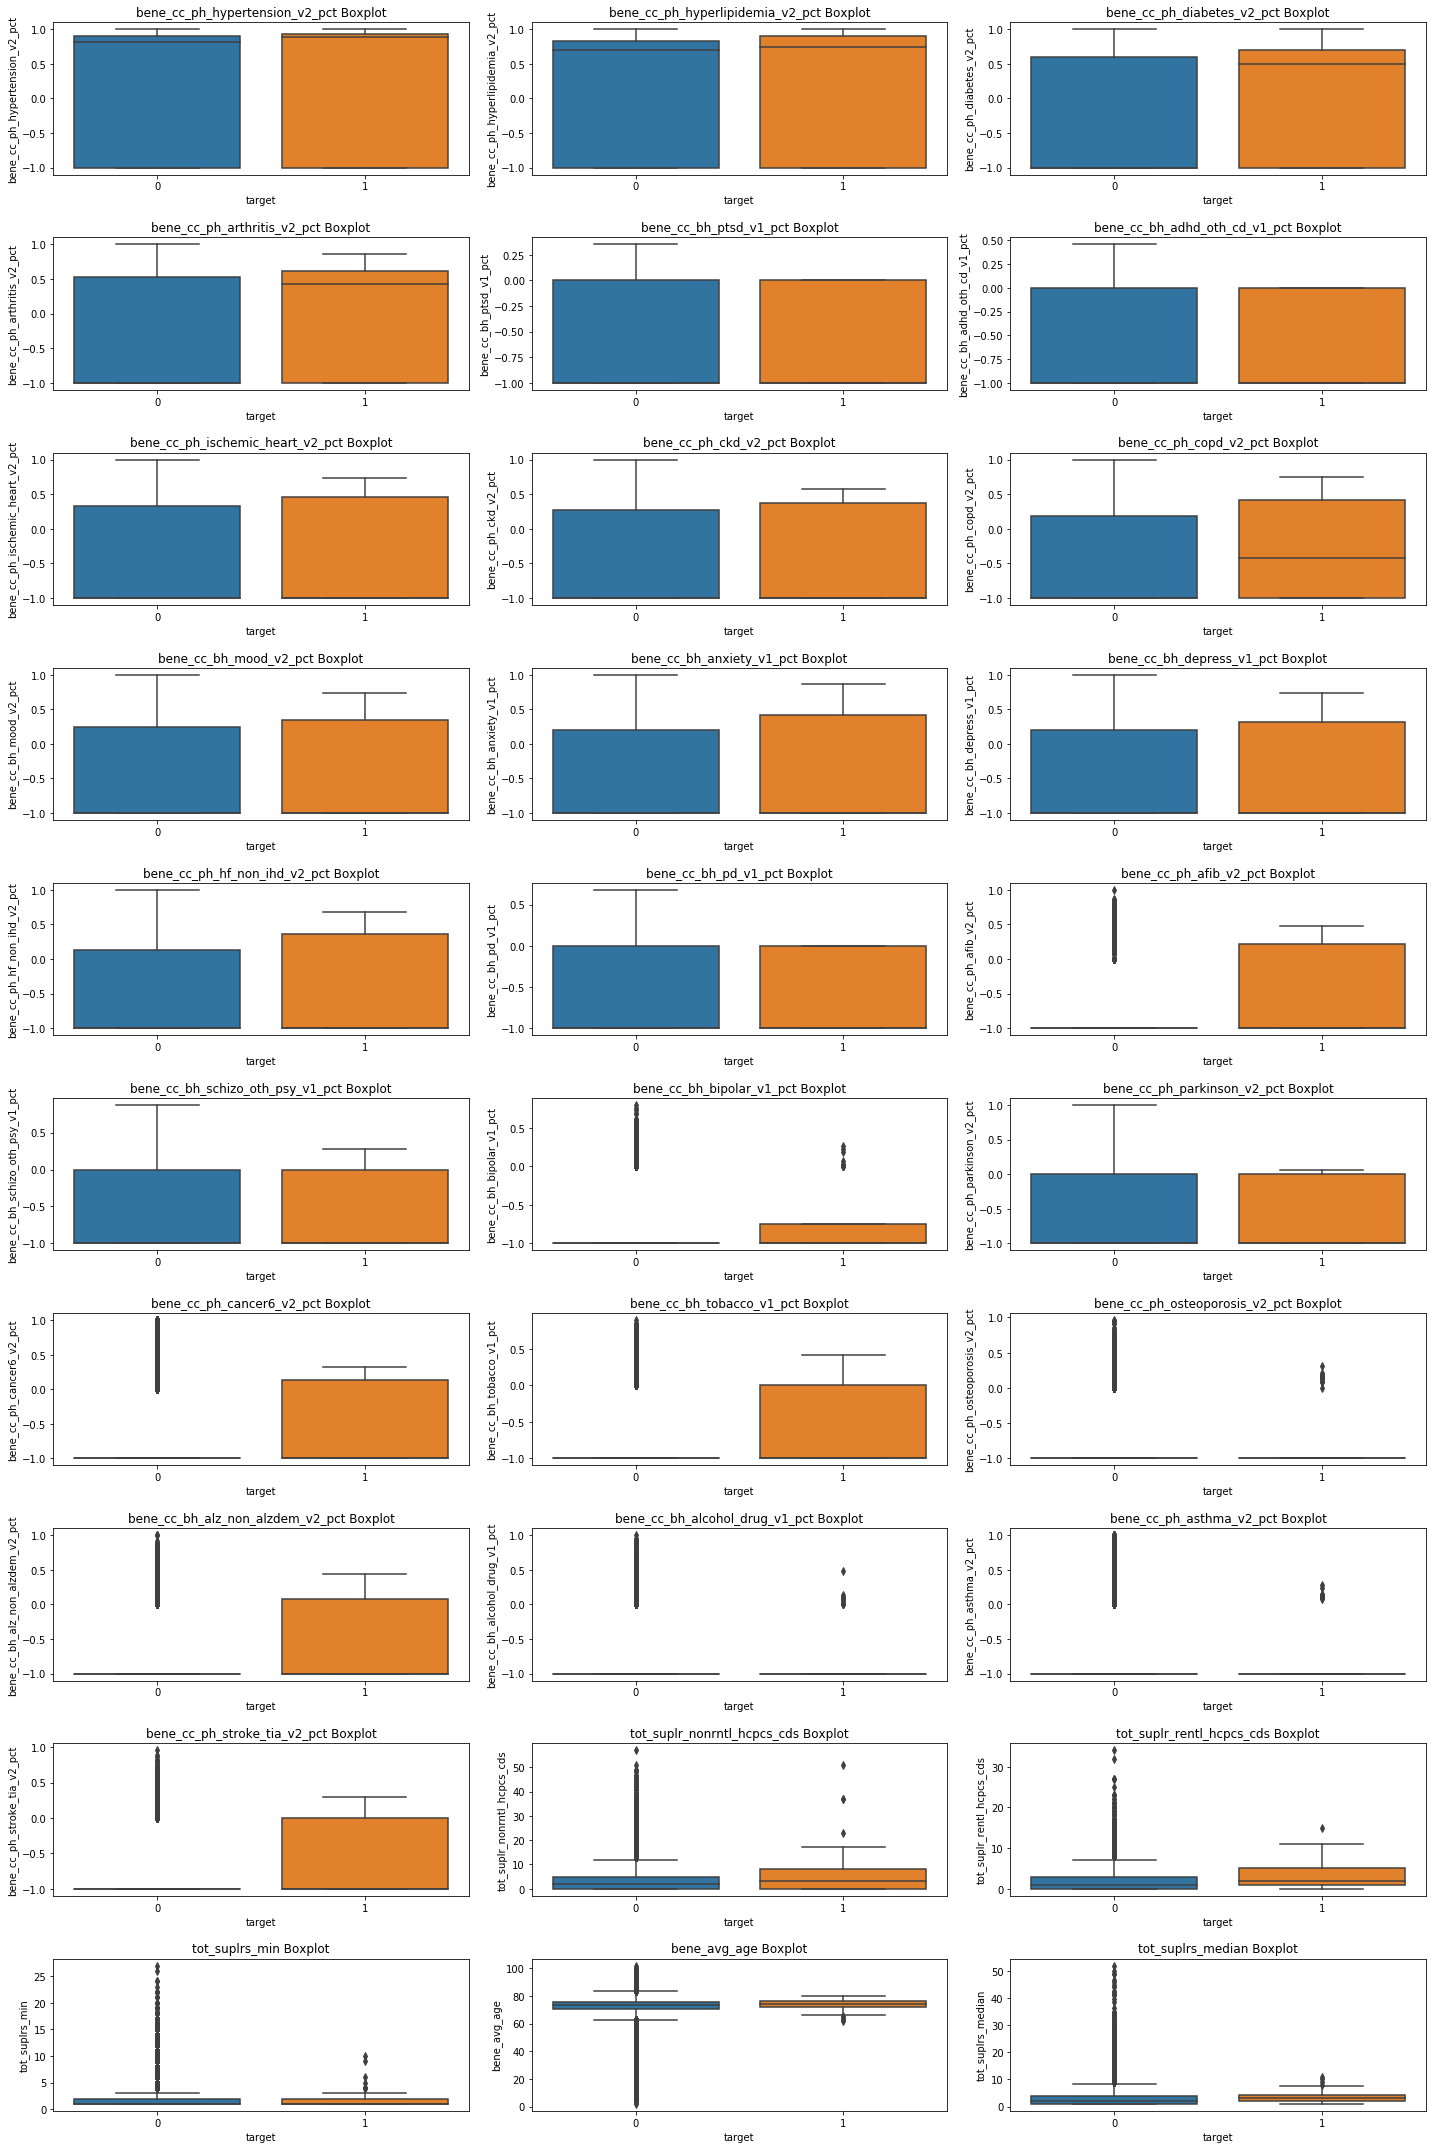

In [32]:
# seperate by fraud/non-fraud
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Which data do I want?
cols = kept_fts.tolist()
cols.append("target")
cols = pd.Index(cols)
data = df.loc[:,cols]

# Set figure size for high volume
fig, axes = plt.subplots(10, 3, figsize=(20, 30)) # 10 rows, 3 columns
axes = axes.flatten()

# Iterate and plot
for i in range(len(data.columns)-1):
    sns.boxplot(x=data.iloc[:,-1], y=data.iloc[:, i], ax=axes[i])
    axes[i].set_title(f'{data.columns[i]} Boxplot')

plt.tight_layout()
plt.show()

In [33]:
# calculate totals for each provider specialty
fts = X_tot.columns
df_spec = df.drop(fts, axis=1).drop(['npi','rfrg_prvdr_state_abrvtn'], axis=1) # year, target, and one-hot-encoded columns
df_spec = pd.get_dummies(df_spec, drop_first = False, dtype = float) # one-hot encode the specialties
spec_tots = df_spec.drop('year', axis=1).groupby('target').sum()
spec_tots

,og_specialty_name_addiction_medicine,og_specialty_name_adult_congenital_heart_disease,og_specialty_name_advanced_heart_failure_and_transplant_cardiology,og_specialty_name_allergy_immunology,og_specialty_name_anesthesiology,og_specialty_name_cardiac_surgery,og_specialty_name_cardiology,og_specialty_name_certified_clinical_nurse_specialist,og_specialty_name_certified_nurse_midwife,og_specialty_name_certified_registered_nurse_anesthetist_crna,og_specialty_name_clinic_center,og_specialty_name_clinic_or_group_practice,og_specialty_name_clinical_cardiac_electrophysiology,og_specialty_name_clinical_neuropsychologist,og_specialty_name_colon_rectal_surgery,og_specialty_name_colorectal_surgery_proctology,og_specialty_name_critical_care_intensivists,og_specialty_name_dermatology,og_specialty_name_diagnostic_radiology,og_specialty_name_emergency_medicine,og_specialty_name_endocrinology,og_specialty_name_family_medicine,og_specialty_name_family_practice,og_specialty_name_gastroenterology,og_specialty_name_general_practice,og_specialty_name_general_surgery,og_specialty_name_geriatric_medicine,og_specialty_name_geriatric_psychiatry,og_specialty_name_gynecological_oncology,og_specialty_name_hand_surgery,og_specialty_name_hematology,og_specialty_name_hematology_oncology,og_specialty_name_hematopoietic_cell_transplantation_and_cellular_therapy,og_specialty_name_hospice_and_palliative_care,og_specialty_name_hospital,og_specialty_name_hospitalist,og_specialty_name_infectious_disease,og_specialty_name_internal_medicine,og_specialty_name_interventional_cardiology,og_specialty_name_interventional_pain_management,og_specialty_name_interventional_radiology,og_specialty_name_legal_medicine,og_specialty_name_licensed_clinical_social_worker,og_specialty_name_licensed_practical_nurse,og_specialty_name_maxillofacial_surgery,og_specialty_name_medical_oncology,og_specialty_name_micrographic_dermatologic_surgery,og_specialty_name_military_health_care_provider,og_specialty_name_nephrology,og_specialty_name_neurological_surgery,og_specialty_name_neurology,og_specialty_name_neuropsychiatry,og_specialty_name_neurosurgery,og_specialty_name_nuclear_medicine,og_specialty_name_nurse_practitioner,og_specialty_name_obstetrics_gynecology,og_specialty_name_ophthalmology,og_specialty_name_optometry,og_specialty_name_oral_surgery_dentist_only,og_specialty_name_orthopaedic_surgery,og_specialty_name_orthopedic_surgery,og_specialty_name_osteopathic_manipulative_medicine,og_specialty_name_otolaryngology,og_specialty_name_pain_management,og_specialty_name_pathology,og_specialty_name_pediatric_medicine,og_specialty_name_pediatrics,og_specialty_name_peripheral_vascular_disease,og_specialty_name_pharmacist,og_specialty_name_physical_medicine_and_rehabilitation,og_specialty_name_physician_assistant,og_specialty_name_plastic_and_reconstructive_surgery,og_specialty_name_plastic_surgery,og_specialty_name_podiatry,og_specialty_name_preventive_medicine,og_specialty_name_psychiatry,og_specialty_name_psychiatry_neurology,og_specialty_name_psychologist_clinical,og_specialty_name_pulmonary_disease,og_specialty_name_radiation_oncology,og_specialty_name_registered_nurse,og_specialty_name_rheumatology,og_specialty_name_sleep_medicine,og_specialty_name_specialist,og_specialty_name_specialist_technologist_other,og_specialty_name_sports_medicine,og_specialty_name_student_in_an_organized_health_care_education_training_program,og_specialty_name_surgery,og_specialty_name_surgical_oncology,og_specialty_name_thoracic_surgery,og_specialty_name_thoracic_surgery_cardiothoracic_vascular_surgery,og_specialty_name_undefined_physician_type,og_specialty_name_undersea_and_hyperbaric_medicine,og_specialty_name_urology,og_specialty_name_vascular_surgery
target,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,21.0,3.0,249.0,822.0,170.0,117.0,1499.0,334.0,6.0,2.0,3.0,5.0,178.0,1.0,13.0,418.0,396.0,34.0,35.0,1415.0,2009.0,35.0,30743.0,772.0,828.0,2142.0,460.0,3.0,76.

In [34]:
# filter for target == 1, transpose, and sort descending
spec_tots.loc[1].sort_values(ascending=False)

og_specialty_name_family_practice                                                   22.0
og_specialty_name_internal_medicine                                                 18.0
og_specialty_name_endocrinology                                                      5.0
og_specialty_name_nurse_practitioner                                                 5.0
og_specialty_name_cardiology                                                         3.0
og_specialty_name_hospitalist                                                        2.0
og_specialty_name_general_practice                                                   1.0
og_specialty_name_interventional_radiology                                           0.0
og_specialty_name_hematology_oncology                                                0.0
og_specialty_name_geriatric_medicine                                                 0.0
og_specialty_name_maxillofacial_surgery                                              0.0
og_specialty_name_ger

In [35]:
spec_tots.loc[1][spec_tots.loc[1] > 0.].index # specialties with fraud

Index(['og_specialty_name_cardiology', 'og_specialty_name_endocrinology',
       'og_specialty_name_family_practice',
       'og_specialty_name_general_practice', 'og_specialty_name_hospitalist',
       'og_specialty_name_internal_medicine',
       'og_specialty_name_nurse_practitioner'],
      dtype='object')

These are the only seven specialty descriptions for Medicare providers convicted of fraud and added to the LEIE between 2021 and 2023 in Missouri or its bordering states.

## Bivariate analysis

The purpose of the bivariate analysis is to determine which features may need to be eliminated due to high correlation with another more variable feature. Step one is to create a correlation matrix of the features.

In [36]:
X_tot = X_tot.loc[:,ordered_fts] # reorder features of X_tot
X_corr = X_tot.corr() # calculate correlation matrix
X_corr

,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,hi_risk_hcpcs,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_depress_v1_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_bh_pd_v1_pct,bene_cc_ph_afib_v2_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_stroke_tia_v2_pct,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_min,bene_avg_age,tot_suplrs_median,tot_suplrs_mean,tot_suplrs_sum,bene_avg_risk_scre,tot_suplrs_max,avg_suplr_sbmtd_chrg_mean,avg_suplr_sbmtd_chrg_max,avg_suplr_sbmtd_chrg_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_stdzd_amt_median,bene_age_lt_65_cnt,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_stdzd_amt_min,bene_race_black_cnt,tot_suplr_clms_sum,bene_dual_cnt,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,avg_suplr_mdcr_alowd_amt_max,tot_suplr_benes_sum,tot_suplr_srvcs_mean,bene_age_65_74_cnt,tot_suplr_srvcs_median,tot_suplr_srvcs_min,bene_race_natind_cnt,bene_race_othr_cnt,bene_male_cnt,bene_race_wht_cnt,bene_race_api_cnt,avg_suplr_sbmtd_chrg_sum,bene_age_gt_84_cnt,tot_suplr_clms_max,tot_suplr_srvcs_sum,bene_feml_cnt,bene_ndual_cnt,drug_suplr_mdcr_stdzd_pymt_amt,tot_suplr_srvcs_max,tot_suplr_benes_max,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,bene_age_75_84_cnt,bene_race_hspnc_cnt,tot_suplr_clms_mean,tot_suplr_clms_median,tot_suplr_benes_mean,tot_suplr_benes_median,tot_suplr_clms_min,tot_suplr_benes_min
bene_cc_ph_hypertension_v2_pct,1.000000,0.892248,0.113446,0.701254,0.670562,0.421871,0.508105,0.531050,0.502078,0.450527,0.469362,0.445683,0.442159,0.428426,0.440598,0.383480,0.357657,0.243107,0.326796,0.265430,0.250658,0.243335,0.209639,0.206912,0.217647,0.186716,0.410676,0.303212,0.030564,0.153837,0.296923,0.344700,0.320637,-0.154290,0.376391,-0.088761,0.124753,-0.136722,-0.149624,-0.054253,-0.054878,-0.055263,-0.080413,-0.081516,-0.081407,0.147527,-0.091972,-0.093697,-0.092213,0.145857,0.207861,0.244569,0.089134,0.089302,0.089909,0.181512,0.045540,0.283798,0.015577,0.011847,0.296005,0.162703,0.282750,0.349490,0.171405,0.228097,0.155126,0.218486,0.087352,0.305112,0.178189,0.038196,0.074184,0.197250,0.178663,0.174096,0.173049,0.252441,0.112877,0.166415,0.116813,0.128913,0.095597,0.009178,0.039435
bene_cc_ph_hyperlipidemia_v2_pct,0.892248,1.000000,0.100365,0.732269,0.706228,0.367569,0.448082,0.564649,0.530488,0.461562,0.493739,0.468434,0.465492,0.447476,0.382500,0.403769,0.315152,0.203514,0.267844,0.268735,0.254754,0.236857,0.186590,0.187230,0.213051,0.164121,0.427245,0.295659,0.038437,0.162107,0.314888,0.366637,0.339675,-0.173170,0.401011,-0.084460,0.126103,-0.130730,-0.141280,-0.048886,-0.049560,-0.049432,-0.074233,-0.075399,-0.074756,0.149869,-0.084598,-0.086297,-0.084575,0.142918,0.219583,0.251510,0.092703,0.093358,0.093418,0.195452,0.048969,0.310480,0.018188,0.014918,0.270583,0.149583,0.306335,0.368133,0.161350,0.235034,0.160209,0.231887,0.090274,0.330073,0.192429,0.038244,0.077912,0.216259,0.185309,0.180658,0.180383,0.275402,0.109436,0.174145,0.120579,0.142823,0.106678,0.009186,0.045031
hi_risk_hcpcs,0.113446,0.100365,1.000000,0.219018,0.027657,0.032978,0.051718,0.116624,0.095489,0.191190,0.083804,0.078917,0.083425,0.142279,0.035196,0.117034,-0.033909,-0.000780,-0.003610,0.010877,0.069779,0.036767,-0.002892,0.010229,0.043989,0.038111,0.107170,0.404690,0.053950,0.143629,0.173451,0.195824,0.176346,-0.023302,0.209313,-0.093304,0.065320,-0.

We need to determine an appropriate cutoff for when variables are "highly correlated." To do this, it may be helpful to visualize the overall distribution of correlations in our data.

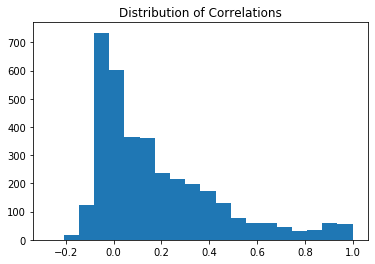

In [37]:
# Extract only upper triangle
corr_values = X_corr.values[np.triu_indices_from(X_corr, k=1)]
# Create the histogram
plt.hist(corr_values, bins=20)
plt.title("Distribution of Correlations")
plt.show()

The distribution of correllations appears to level off after a coefficient of 0.4 possibly growing as the correlation approaches 1.0. We do not eliminate features for multicolinearity at this stage as it is preferable to do this after combining the datasets. However, we conduct a brief analysis of features we expect to be retained at a correlation threshold of 0.85.

In [38]:
# we drop any feature if its corresponding column has an entry > 0.85 in the upper triangle
upper_tri = X_corr.where(np.triu(np.ones(X_corr.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

X_tot_red = X_tot.drop(columns=to_drop, axis=1)
kept_fts = X_tot_red.columns # gather the kept features

X_tot_red.head()

,bene_cc_ph_hypertension_v2_pct,hi_risk_hcpcs,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_bh_pd_v1_pct,bene_cc_ph_afib_v2_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_stroke_tia_v2_pct,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_min,bene_avg_age,tot_suplrs_median,tot_suplrs_sum,bene_avg_risk_scre,avg_suplr_sbmtd_chrg_mean,avg_suplr_sbmtd_chrg_max,bene_age_lt_65_cnt,bene_race_black_cnt,tot_suplr_clms_sum,bene_dual_cnt,avg_suplr_mdcr_pymt_amt_max,tot_suplr_srvcs_mean,bene_race_natind_cnt,bene_race_othr_cnt,bene_race_api_cnt,avg_suplr_sbmtd_chrg_sum,bene_age_gt_84_cnt,tot_suplr_clms_max,tot_suplr_srvcs_sum,drug_suplr_mdcr_stdzd_pymt_amt,bene_race_hspnc_cnt,tot_suplr_clms_min
0,0.812500,0,-1.000000,-1.000000,0.0,0.0,-1.0,-1.000000,-1.000000,-1.0,-1.000000,-1.0,0.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,-1.0,-1.0,0.0,1.0,0.0,3,69.187500,3.0,3,1.822832,6.155416,6.155416,-1.0,-1.0,44,-1.0,1.692306,5955.000,-1.0,0.0,0.0,6.155416,-1.0,44,5955,0.00,0.0,44
1,0.857143,0,-1.000000,-1.000000,0.0,0.0,-1.0,-1.000000,-1.000000,-1.0,-1.000000,-1.0,0.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,-1.0,5.0,0.0,1,72.000000,3.0,12,1.717712,12.431501,25.536875,-1.0,0.0,155,-1.0,8.331875,3837.000,-1.0,-1.0,0.0,62.157505,-1.0,59,19185,0.00,0.0,17
2,0.967742,1,0.709677,0.516129,0.0,0.0,-1.0,0.419355,0.419355,-1.0,0.451613,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,5.0,3.0,1,71.677419,2.5,32,1.839028,97.751851,389.755000,-1.0,-1.0,155,14.0,82.163333,256.625,0.0,-1.0,0.0,782.014805,-1.0,32,2053,206.08,0.0,12
3,0.913043,1,0.652174,0.521739,0.0,0.0,-1.0,-1.000000,-1.000000,-1.0,-1.000000,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,4.0,1.0,1,68.130435,3.0,23,1.358490,80.839496,250.000000,-1.0,0.0,90,-1.0,38.227500,502.400,0.0,0.0,0.0,404.197480,-1.0,32,2512,174.40,0.0,11
4,0.875000,1,0.500000,-1.000000,0.0,-1.0,-1.0,-1.000000,-1.000000,-1.0,0.458333,-1.0,0.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,3.0,1.0,1,69.708333,3.5,13,1.498885,39.630693,63.796190,-1.0,-1.0,63,-1.0,24.145333,437.000,0.0,-1.0,0.0,158.522774,-1.0,23,1748,0.00,0.0,11


In [39]:
X_tot.loc[:,kept_fts].corr() # calc correlation matrix for retained features

,bene_cc_ph_hypertension_v2_pct,hi_risk_hcpcs,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_bh_pd_v1_pct,bene_cc_ph_afib_v2_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_stroke_tia_v2_pct,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_min,bene_avg_age,tot_suplrs_median,tot_suplrs_sum,bene_avg_risk_scre,avg_suplr_sbmtd_chrg_mean,avg_suplr_sbmtd_chrg_max,bene_age_lt_65_cnt,bene_race_black_cnt,tot_suplr_clms_sum,bene_dual_cnt,avg_suplr_mdcr_pymt_amt_max,tot_suplr_srvcs_mean,bene_race_natind_cnt,bene_race_othr_cnt,bene_race_api_cnt,avg_suplr_sbmtd_chrg_sum,bene_age_gt_84_cnt,tot_suplr_clms_max,tot_suplr_srvcs_sum,drug_suplr_mdcr_stdzd_pymt_amt,bene_race_hspnc_cnt,tot_suplr_clms_min
bene_cc_ph_hypertension_v2_pct,1.000000,0.113446,0.701254,0.670562,0.421871,0.508105,0.531050,0.502078,0.450527,0.469362,0.445683,0.428426,0.440598,0.383480,0.357657,0.243107,0.326796,0.265430,0.250658,0.243335,0.209639,0.206912,0.217647,0.186716,0.410676,0.303212,0.030564,0.153837,0.296923,0.320637,-0.154290,-0.088761,0.124753,0.147527,0.145857,0.207861,0.244569,0.089134,0.045540,0.296005,0.162703,0.171405,0.228097,0.155126,0.218486,0.087352,0.038196,0.112877,0.009178
hi_risk_hcpcs,0.113446,1.000000,0.219018,0.027657,0.032978,0.051718,0.116624,0.095489,0.191190,0.083804,0.078917,0.142279,0.035196,0.117034,-0.033909,-0.000780,-0.003610,0.010877,0.069779,0.036767,-0.002892,0.010229,0.043989,0.038111,0.107170,0.404690,0.053950,0.143629,0.173451,0.176346,-0.023302,-0.093304,0.065320,0.010431,0.023362,0.096770,0.079727,-0.030280,-0.073155,0.035605,0.044371,0.029447,0.141024,0.058274,0.078966,0.005233,0.031081,0.018452,-0.048008
bene_cc_ph_diabetes_v2_pct,0.701254,0.219018,1.000000,0.658475,0.207369,0.283195,0.630393,0.624803,0.488252,0.546224,0.515588,0.504684,0.222962,0.470092,0.142407,0.079798,0.111934,0.255351,0.263859,0.243935,0.122628,0.106133,0.198642,0.125045,0.479008,0.322915,0.073202,0.096624,0.377772,0.387210,-0.100513,-0.088600,0.137244,0.179790,0.175500,0.238469,0.317652,0.078097,0.042793,0.218436,0.103853,0.133889,0.261017,0.174660,0.263691,0.090779,0.040800,0.107159,-0.006169
bene_cc_ph_arthritis_v2_pct,0.670562,0.027657,0.658475,1.000000,0.153703,0.230698,0.676514,0.613726,0.545224,0.636105,0.607319,0.545228,0.169728,0.510814,0.124481,0.030199,0.058596,0.304819,0.274453,0.246647,0.139659,0.052683,0.213113,0.116244,0.470552,0.364460,-0.076669,0.137957,0.228473,0.377678,-0.140611,-0.044932,0.163206,0.178085,0.167624,0.258796,0.322979,0.139265,0.057770,0.198765,0.107333,0.121227,0.285467,0.212229,0.260175,0.107286,0.051576,0.092216,0.006570
bene_cc_bh_ptsd_v1_pct,0.421871,0.032978,0.207369,0.153703,1.000000,0.503992,0.059126,0.052280,0.010385,-0.041910,-0.056801,0.011217,0.492783,-0.009477,0.431086,0.360235,0.362061,0.004916,-0.005704,0.005205,0.130843,0.234660,-0.000559,0.083036,0.014256,-0.019206,0.083264,0.158794,0.086353,-0.038710,-0.125566,-0.061352,-0.034228,-0.073189,-0.013459,-0.053912,-0.086334,-0.034974,-0.025129,0.182435,0.086969,0.117576,-0.037818,-0.037305,-0.054654,-0.037933,-0.018008,0.044113,0.003772
bene_cc_bh_adhd_oth_cd_v1_pct,0.508105,0.051718,0.283195,0.230698,0.503992,1.000000,0.126128,0.107710,0.091847,0.029496,0.022379,0.065350,0.511323,0.026223,0.447162,0.340469,0.399870,0.022441,0.034102,0.022620,0.128013,0.215019,0.018863,0.085260,0.042838,0.022517,0.077033,0.141804,0.096161,-0.027434,-0.131378,-0.061830,-0.007656,-0.077926,-0.010104,-0.063416,-0.069338,-0.013299,-0.020410,0.205665,0.086812,0.133408,-0.007843,-0.052582,-0.052981,-0.042817,-0.016811,0.05434

In [40]:
# a function that plots correlations as ellipses
from matplotlib.collections import EllipseCollection

def plot_corr_ellipses(data, ax=None, **kwargs):

    M = np.array(data)
    if not M.ndim == 2:
        raise ValueError('data must be a 2D array')
    if ax is None:
        fig, ax = plt.subplots(1, 1, subplot_kw={'aspect':'equal'})
        ax.set_xlim(-0.5, M.shape[1] - 0.5)
        ax.set_ylim(-0.5, M.shape[0] - 0.5)

    # xy locations of each ellipse center
    xy = np.indices(M.shape)[::-1].reshape(2, -1).T

    # set the relative sizes of the major/minor axes according to the strength of
    # the positive/negative correlation
    w = np.ones_like(M).ravel()
    h = 1 - np.abs(M).ravel()
    a = 45 * np.sign(M).ravel()

    ec = EllipseCollection(widths=w, heights=h, angles=a, units='x', offsets=xy,
                           transOffset=ax.transData, array=M.ravel(), **kwargs)
    ax.add_collection(ec)

    # if data is a DataFrame, use the row/column names as tick labels
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(M.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(data.index)

    return ec

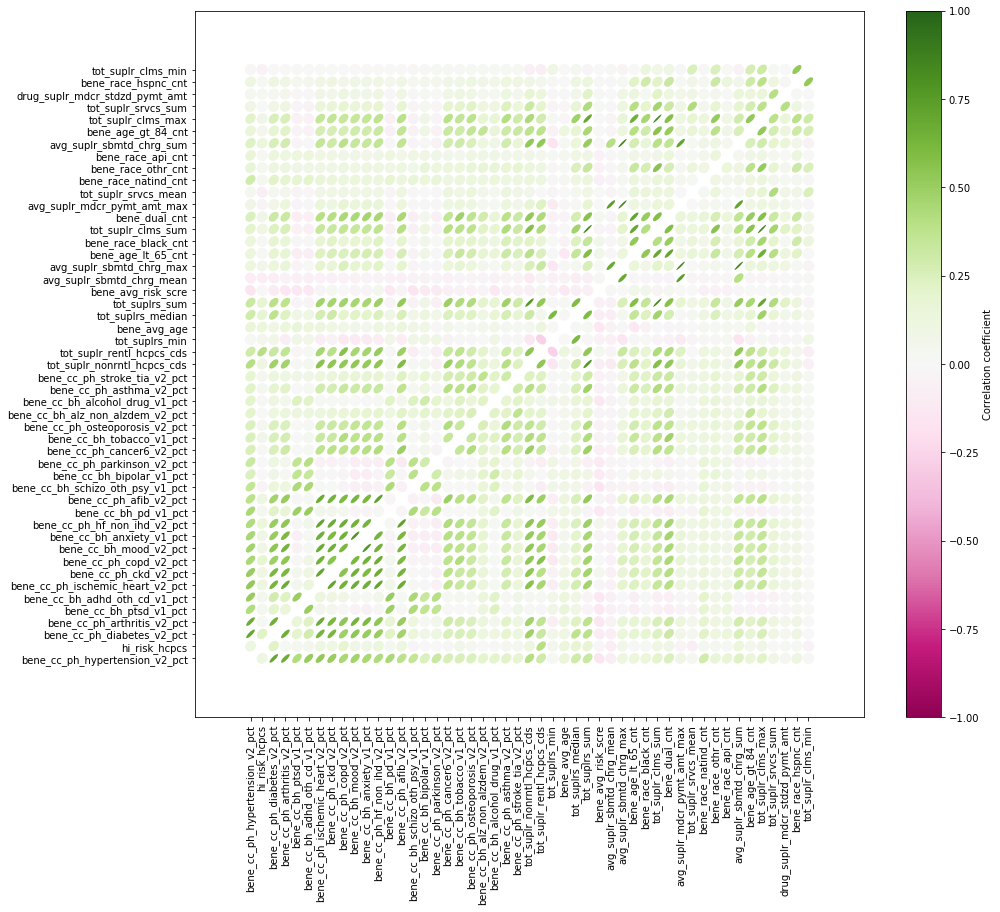

In [41]:
from matplotlib.colors import DivergingNorm # need to use TwoSlopeNorm outside of Jupyter

fig, ax = plt.subplots(1, 1, figsize=(15,13))
m = plot_corr_ellipses(X_tot.loc[:,kept_fts].corr(), ax=ax, cmap='PiYG', norm=DivergingNorm(0, vmin=-1, vmax=1))
cb = fig.colorbar(m)
cb.set_label('Correlation coefficient')
ax.margins(0.1)

We observe some interesting correlations between variables. For example, the correlation between `tot_suplr_clms_max` and `bene_age_lt_65_cnt` and the correlation between `tot_suplrs_sum` and `tot_suplrs_nonrentl_hcpcs_cds` are relatively strong. The latter is interesting because it appears substantially stronger than the correlation between `tot_suplrs_sum` and `tot_suplrs_rentl_hcpcs_cds`.

## Wilcoxon rank-sum test on numeric features

In [2]:
from scipy import stats

df_num = df.loc[:,'target':'bene_avg_risk_scre']

feats = df_num.columns[1:]

results = {}

for feat in feats:
    stat, pval = stats.ranksums(df_num[df_num['target']==0][feat], df_num[df_num['target']==1][feat])
    results[feat] = (stat, pval)

results

{'avg_suplr_sbmtd_chrg_mean': (-1.3677610670060036, 0.17138687800303853),
 'avg_suplr_mdcr_alowd_amt_mean': (-1.9108587431498192, 0.056022736203657594),
 'avg_suplr_mdcr_pymt_amt_mean': (-1.9154270372665871, 0.05543806582281282),
 'avg_suplr_mdcr_stdzd_amt_mean': (-1.6184254528985385, 0.105570940359192),
 'tot_suplr_mdcr_pymt_amt_mean': (-3.050999089944775, 0.002280812660162832),
 'tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean': (-3.178712417841794,
  0.0014793078154671038),
 'avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean': (-1.440758428844505,
  0.14965294158313247),
 'avg_suplr_sbmtd_chrg_sum': (-2.851333896811725, 0.004353622599429947),
 'avg_suplr_mdcr_alowd_amt_sum': (-2.997190536031798, 0.0027248035055062853),
 'avg_suplr_mdcr_pymt_amt_sum': (-2.9316464471423522, 0.003371703537784227),
 'avg_suplr_mdcr_stdzd_amt_sum': (-2.8749660652977473, 0.004040709237690603),
 'tot_suplr_mdcr_pymt_amt_sum': (-3.1421874351212233, 0.0016769064929553043),
 'tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_

In [3]:
min_p = min(results[key][1] for key in results)
for key in results:
    if results[key][1] == min_p:
        print(f'{key}: {results[key]}')

tot_suplr_clms_max: (-3.476018116787605, 0.0005089179057526364)


In [4]:
for key in results:
    if results[key][1] < 0.001:
        print(f'{key}: {results[key]}')

tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max: (-3.3796598237891944, 0.0007257559681494714)
tot_suplr_clms_mean: (-3.368858002759586, 0.0007548030359973057)
tot_suplr_clms_max: (-3.476018116787605, 0.0005089179057526364)
bene_cc_bh_anxiety_v1_pct: (-3.355476961338035, 0.0007922825539564692)


The class values are shown to be most-significantly different for `tot_suplr_clms_max` with the fraud class lower with p-value = 0.00051. The fields `tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max`, `tot_suplr_clms_mean`, and `bene_cc_bh_anxiety_v1_pct` also show lower values for the fraud class with a p-value on the order of magnitude of the class imbalance ratio.